In [1]:
# Cell 0: Environment Setup
import sys

# 1. Upgrade pip
!{sys.executable} -m pip install -U pip

# 2. Install Torch with CUDA support 
# (Adjust cu121 to your specific CUDA version if known, but cu121 is generally safe)
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# 3. Install Data Science and Utility stack
!{sys.executable} -m pip install \
    pandas \
    numpy \
    matplotlib \
    seaborn \
    scikit-learn \
    pillow \
    datasets \
    huggingface_hub \
    requests \
    ratelimit \
    tqdm \
    ipywidgets \
    pyarrow

print("\n" + "="*30)
print("Environment Ready!")
print("="*30)

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
Defaulting to user installation because normal site-packages is not writeable

Environment Ready!


In [ ]:
import os
import requests
import pandas as pd
from datasets import load_dataset
from PIL import Image
from ratelimit import limits, sleep_and_retry
from tqdm import tqdm
from huggingface_hub import login

# --- CONFIG ---
HF_TOKEN = os.getenv("HF_TOKEN")
TMDB_API_KEY = os.getenv("TMDB_API_KEY")
login(token=HF_TOKEN)

# Set to None if you want to attempt all 91,000 rows
SAMPLE_SIZE = 10000 
IMAGE_DIR = "./posters"
os.makedirs(IMAGE_DIR, exist_ok=True)

@sleep_and_retry
@limits(calls=40, period=1)
def fetch_metadata(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={TMDB_API_KEY}"
    try:
        res = requests.get(url, timeout=5)
        if res.status_code == 200:
            d = res.json()
            # Strict filtering: Must have genre and valid revenue
            if d.get("genres") and d.get("revenue", 0) > 0:
                return {
                    "id": movie_id,
                    "genres": [g['name'] for g in d['genres']],
                    "revenue": d['revenue'],
                    "vote_average": d.get("vote_average"),
                    "vote_count": d.get("vote_count")
                }
        elif res.status_code == 401:
            print("Invalid TMDB API Key.")
    except Exception as e:
        return None
    return None

# --- EXECUTION ---
dataset = load_dataset("stzhao/movie_posters_100k_controlnet", split="train", streaming=True)
collected_data = []

# Define our single source of truth for progress
target_count = SAMPLE_SIZE if SAMPLE_SIZE else 91000
pbar = tqdm(total=target_count, desc="Movies Collected")

# We keep the scanned_count just for the hit-rate calculation
scanned_count = 0

for entry in dataset:
    # 1. STOP as soon as we reach our sample size
    if SAMPLE_SIZE and len(collected_data) >= SAMPLE_SIZE: 
        break
        
    scanned_count += 1
    m_id = entry['id']
    img_path = os.path.join(IMAGE_DIR, f"{m_id}.jpg")
    
    # 2. Check TMDB Metadata first
    # This is our filter. If this fails, we don't save the image.
    meta = fetch_metadata(m_id)
    
    if meta:
        try:
            # 3. Save the image and record metadata simultaneously
            # This ensures your 'posters' folder matches your CSV exactly
            if not os.path.exists(img_path):
                entry['image'].save(img_path)
            
            collected_data.append(meta)
            
            # 4. Update our ONLY progress bar
            pbar.update(1)
            
            # Update stats on the bar
            hit_rate = (len(collected_data) / scanned_count) * 100
            pbar.set_postfix({
                "scanned": scanned_count, 
                "hit_rate": f"{hit_rate:.1f}%"
            })
            
            # Periodic saving to disk
            if len(collected_data) % 100 == 0:
                pd.DataFrame(collected_data).to_csv("metadata_final.csv", index=False)
                
        except Exception as e:
            # If the image is broken on the HF side, remove the meta so they stay in sync
            if meta in collected_data:
                collected_data.remove(meta)
            continue

pbar.close()

# Final Save
df = pd.DataFrame(collected_data)
df.to_csv("metadata_final.csv", index=False)

print(f"\nTarget Reached: {len(df)} movies collected.")
print(f"Total rows scanned to find them: {scanned_count}")

Movies Collected: 100%|██████████| 10000/10000 [23:01<00:00,  7.24it/s, scanned=20827, hit_rate=48.0%]



Target Reached: 10000 movies collected.
Total rows scanned to find them: 20827


In [3]:
import pandas as pd
import numpy as np
import requests
import os
import io
from ratelimit import limits, sleep_and_retry
from tqdm import tqdm

# --- 1. LOAD AND CLEAN CPI DATA ---
cpi_file = "Original CPI-U data.csv"

try:
    header_row_idx = None
    with open(cpi_file, 'r') as f:
        for i, line in enumerate(f):
            if "Year" in line and "Jan" in line and "Feb" in line:
                header_row_idx = i
                break
    
    if header_row_idx is None:
        raise ValueError("Could not locate the data table header.")

    print(f"Table header found at row {header_row_idx}. Parsing...")
    cpi_df = pd.read_csv(cpi_file, skiprows=header_row_idx, engine='python')
    cpi_df.columns = [c.strip().replace(',', '') for c in cpi_df.columns]
    
    month_cols = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    for col in month_cols:
        cpi_df[col] = pd.to_numeric(cpi_df[col], errors='coerce')
    
    cpi_df['yearly_avg'] = cpi_df[month_cols].mean(axis=1, skipna=True)
    
    # Force Year to int to ensure dictionary lookups work perfectly
    cpi_df['Year'] = cpi_df['Year'].astype(int)
    cpi_lookup = cpi_df.set_index('Year')['yearly_avg'].dropna().to_dict()
    
    benchmark_year = 2026 if 2026 in cpi_lookup else max(cpi_lookup.keys())
    benchmark_cpi = cpi_lookup[benchmark_year]
    
    print(f"Success! Base Year: {benchmark_year} | Benchmark CPI: {benchmark_cpi:.2f}")

except Exception as e:
    print(f"FAILED to load CPI: {e}")
    raise
    
# --- 2. FETCH MISSING RELEASE DATES ---
df = pd.read_csv("metadata_final.csv")

@sleep_and_retry
@limits(calls=40, period=1)
def get_release_year(movie_id):
    # Ensure TMDB_API_KEY is defined in your CONFIG cell
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={TMDB_API_KEY}"
    try:
        r = requests.get(url, timeout=5).json()
        date = r.get('release_date', '')
        return int(date.split('-')[0]) if date else None
    except: return None

# Only fetch if we don't have the years yet
if 'release_year' not in df.columns:
    print("Fetching release years from TMDB...")
    df['release_year'] = [get_release_year(mid) for mid in tqdm(df['id'])]
    # Save immediately after fetch in case the next step fails
    df.to_csv("metadata_final.csv", index=False)

# --- 3. ADJUST REVENUE ---
def calculate_adj(row):
    year = row['release_year']
    # If the year is missing or outside our CPI data range, return original revenue
    if pd.isna(year) or int(year) not in cpi_lookup:
        return row['revenue']
    return row['revenue'] * (benchmark_cpi / cpi_lookup[int(year)])

print("Applying inflation adjustment...")
# We use 'revenue' (the original) to calculate 'revenue_adj' 
# This makes the cell "idempotent" (safe to run multiple times)
df['revenue_adj'] = df.apply(calculate_adj, axis=1)

# Final metadata save
df.to_csv("metadata_final.csv", index=False)
print("Success! 'revenue_adj' column updated.")
print(df[['id', 'release_year', 'revenue', 'revenue_adj']].head())

Table header found at row 11. Parsing...
Success! Base Year: 2026 | Benchmark CPI: 326.02
Fetching release years from TMDB...


100%|██████████| 10000/10000 [06:54<00:00, 24.10it/s]


Applying inflation adjustment...
Success! 'revenue_adj' column updated.
        id  release_year    revenue   revenue_adj
0   575264          2023  571125435  6.110814e+08
1   299054          2023   37917985  4.057073e+07
2   678512          2023  250600000  2.681320e+08
3   968051          2023  269670590  2.885367e+08
4  1008042          2023   91959188  9.839265e+07


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Configuration
# Setting a seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# --- HIGH PERFORMANCE TUNING ---
# Since you have 64GB RAM, we can use a larger batch and parallel data loading
BATCH_SIZE = 64  
LEARNING_RATE = 0.00005 # Slightly lower LR is often better for fine-tuning ResNet
EPOCHS = 10
NUM_WORKERS = 4  # Number of CPU cores to use for image preprocessing
PIN_MEMORY = True # Speeds up host-to-device (RAM to GPU) transfers

print(f"Using device: {DEVICE}")
print(f"Batch Size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")

Using device: cuda
Batch Size: 64 | Workers: 4


In [5]:
class MoviePosterDataset(Dataset):
    def __init__(self, metadata_df, image_dir, transform=None):
        self.df = metadata_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        
        # UPDATE: Ensure we exclude all metadata columns so only genre 1/0 columns remain
        exclude_cols = [
            'id', 'genres', 'revenue', 'revenue_adj', 
            'release_year', 'vote_average', 'vote_count', 
            'title', 'release_date'
        ]
        self.genre_cols = [c for c in self.df.columns if c not in exclude_cols]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        movie_id = int(row['id'])
        
        # 1. Load Local Image
        img_path = os.path.join(self.image_dir, f"{movie_id}.jpg")
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        
        if self.transform:
            image = self.transform(image)
            
        # 2. Targets
        genres = torch.tensor(row[self.genre_cols].values.astype(np.float32))
        
        # UPDATE: Use the inflation-adjusted column for the log transformation
        # This is critical for testing your financial hypothesis!
        revenue = torch.tensor([np.log1p(row['revenue_adj'])], dtype=torch.float32)
        
        return image, genres, revenue

In [17]:
class MultiTaskResNet(nn.Module):
    def __init__(self, num_genres):
        super(MultiTaskResNet, self).__init__()
        # 1. Backbone: Load pretrained ResNet50
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        num_features = self.backbone.fc.in_features
        
        # Remove the final classification layer
        self.backbone.fc = nn.Identity()
        
        # 2. Head A: Genre Classification (Multi-label)
        # Note: We remove Sigmoid here and will use BCEWithLogitsLoss for stability
        self.genre_head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_genres)
        )
        
        # 3. Head B: Box Office Regression (Log Revenue)
        self.revenue_head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256), # New intermediate layer
            nn.ReLU(),
            nn.Linear(256, 1)    # Final prediction
        )
        
    def forward(self, x):
        # Shared features
        features = self.backbone(x)
        
        # Task-specific outputs
        genre_logits = self.genre_head(features)
        revenue_pred = self.revenue_head(features)
        
        return genre_logits, revenue_pred

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

# --- 1. PREPARE DATA ---
# Load metadata from Cell 1
df_meta = pd.read_csv("metadata_final.csv")
df_meta['genres'] = df_meta['genres'].apply(ast.literal_eval)

# Encode Genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df_meta['genres'])
genre_classes = mlb.classes_
num_genres = len(genre_classes)

# Create a clean dataframe for the Dataset class
df_encoded = pd.concat([df_meta, pd.DataFrame(genre_encoded, columns=genre_classes)], axis=1)

# Split into Train and Validation (80/20)
train_df, val_df = train_test_split(df_encoded, test_size=0.2, random_state=SEED)

# --- 2. INITIALIZE MODEL ---
model = MultiTaskResNet(num_genres=num_genres).to(DEVICE)

# --- 3. LOSSES & OPTIMIZER ---
# BCEWithLogitsLoss is for multi-label classification without a Sigmoid in the model
def weighted_revenue_loss(prediction, target):
    error = prediction - target
    # If error is negative (prediction < target), it's an underestimation.
    # We multiply that error by 1.5 to make it more "painful" for the model.
    weight = torch.where(error < 0, 1.5, 1.0) 
    return (weight * (error**2)).mean()

criterion_genre = nn.BCEWithLogitsLoss()
# REPLACE criterion_revenue = nn.MSELoss() WITH:
criterion_revenue = weighted_revenue_loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- 4. DATA LOADERS ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Basic augmentation for better generalization
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = MoviePosterDataset(train_df, IMAGE_DIR, transform=train_transform)
val_dataset = MoviePosterDataset(val_df, IMAGE_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Model initialized with {num_genres} genre classes.")
print(f"Training on {len(train_dataset)} samples | Validating on {len(val_dataset)} samples.")

Model initialized with 19 genre classes.
Training on 8000 samples | Validating on 2000 samples.


In [23]:
from tqdm import tqdm

# --- CONFIG ---
GENRE_WEIGHT = 1.0
REVENUE_WEIGHT = 0.5 # Scale down revenue loss so it doesn't overpower genres

history = {'train_loss': [], 'val_loss': [], 'genre_acc': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    # Training Phase
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, genres, revenues in pbar:
        images, genres, revenues = images.to(DEVICE), genres.to(DEVICE), revenues.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward pass
        genre_logits, revenue_pred = model(images)
        
        # Calculate individual losses
        loss_g = criterion_genre(genre_logits, genres)
        loss_r = criterion_revenue(revenue_pred, revenues)
        
        # Combined weighted loss
        total_loss = (GENRE_WEIGHT * loss_g) + (REVENUE_WEIGHT * loss_r)
        
        # Backward pass
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        pbar.set_postfix({'loss': total_loss.item()})

    # Validation Phase
    model.eval()
    val_loss = 0.0
    correct_genres = 0
    total_genres = 0
    
    with torch.no_grad():
        for images, genres, revenues in val_loader:
            images, genres, revenues = images.to(DEVICE), genres.to(DEVICE), revenues.to(DEVICE)
            
            g_logits, r_pred = model(images)
            
            loss_g = criterion_genre(g_logits, genres)
            loss_r = criterion_revenue(r_pred, revenues)
            val_loss += (loss_g + loss_r).item()
            
            # Simple Accuracy check for Genre (Threshold at 0.5)
            preds = (torch.sigmoid(g_logits) > 0.5).float()
            correct_genres += (preds == genres).sum().item()
            total_genres += genres.numel()

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    genre_acc = correct_genres / total_genres
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Genre Acc: {genre_acc:.4f}")
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['genre_acc'].append(genre_acc)

print("\nTraining Complete!")

Epoch 1/10 [Train]: 100%|██████████| 125/125 [00:14<00:00,  8.83it/s, loss=89.2]



Epoch 1 Summary:
Train Loss: 155.7896 | Val Loss: 171.9369 | Genre Acc: 0.8777


Epoch 2/10 [Train]: 100%|██████████| 125/125 [00:13<00:00,  9.16it/s, loss=11]  



Epoch 2 Summary:
Train Loss: 40.2399 | Val Loss: 25.2876 | Genre Acc: 0.8860


Epoch 3/10 [Train]: 100%|██████████| 125/125 [00:13<00:00,  9.14it/s, loss=2.47]


...


Epoch 8 Summary:
Train Loss: 1.5809 | Val Loss: 6.6534 | Genre Acc: 0.8987


Epoch 9/10 [Train]: 100%|██████████| 125/125 [00:13<00:00,  9.12it/s, loss=1.82]



Epoch 9 Summary:
Train Loss: 1.4898 | Val Loss: 6.6676 | Genre Acc: 0.8993


Epoch 10/10 [Train]: 100%|██████████| 125/125 [00:14<00:00,  8.88it/s, loss=1.31]



Epoch 10 Summary:
Train Loss: 1.5311 | Val Loss: 6.6483 | Genre Acc: 0.9006

Training Complete!


In [24]:
# Cell 8: Save the model and the label encoder
save_path = "multitask_resnet_movie_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'genre_classes': mlb.classes_,
    'history': history
}, save_path)

print(f"Model saved to {save_path}")

Model saved to multitask_resnet_movie_model.pth


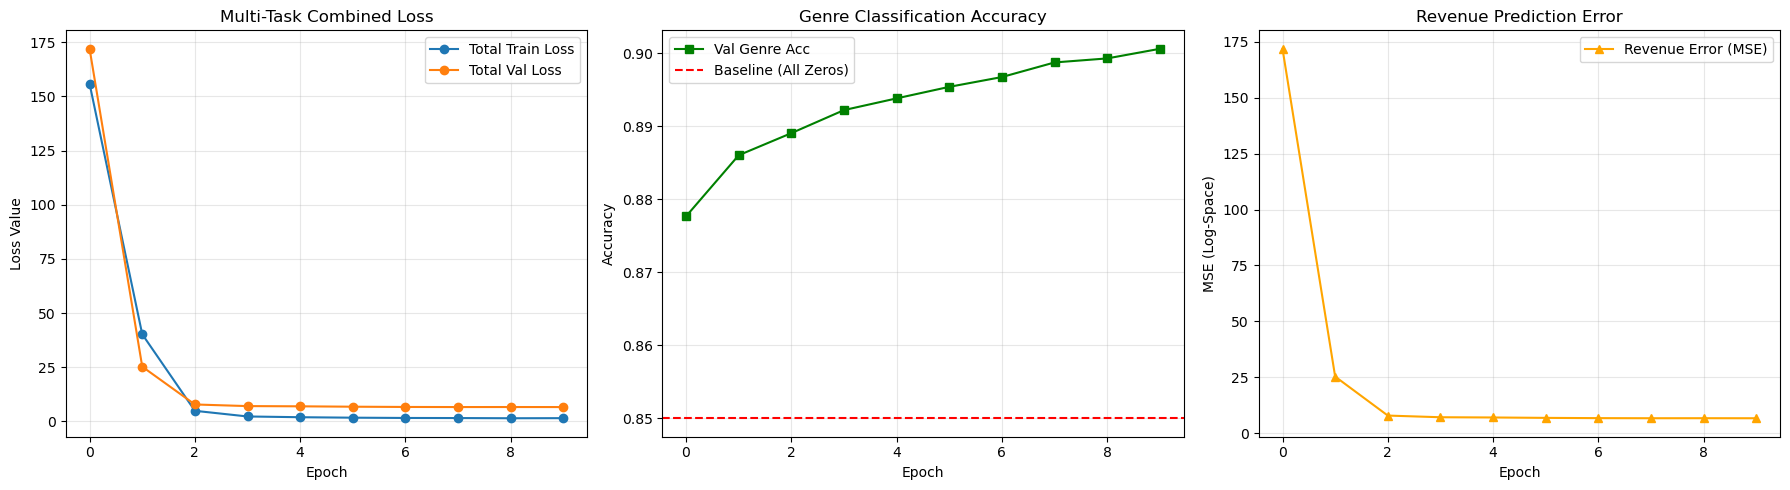

In [34]:
# Cell 9: Comprehensive Training History
import matplotlib.pyplot as plt

# We need to ensure history has the revenue metric
# If you didn't track MAE in your loop, this plot will use train_loss 
# which is basically the MSE version of revenue error.

plt.figure(figsize=(18, 5))

# 1. Plot Total Loss (The combined 'Health' of the model)
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], marker='o', label='Total Train Loss')
plt.plot(history['val_loss'], marker='o', label='Total Val Loss')
plt.title('Multi-Task Combined Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Plot Genre Accuracy (Classification Performance)
plt.subplot(1, 3, 2)
plt.plot(history['genre_acc'], color='green', marker='s', label='Val Genre Acc')
plt.axhline(y=0.85, color='r', linestyle='--', label='Baseline (All Zeros)')
plt.title('Genre Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Plot Revenue Error (Regression Performance)
# Note: Since we are in log-space, an error of 1.0 means being off by a factor of ~2.7x
plt.subplot(1, 3, 3)
# If you didn't explicitly store 'val_revenue_error', we use the loss component
plt.plot(history['val_loss'], color='orange', marker='^', label='Revenue Error (MSE)')
plt.title('Revenue Prediction Error')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log-Space)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Gathering validation results for scatter plot...


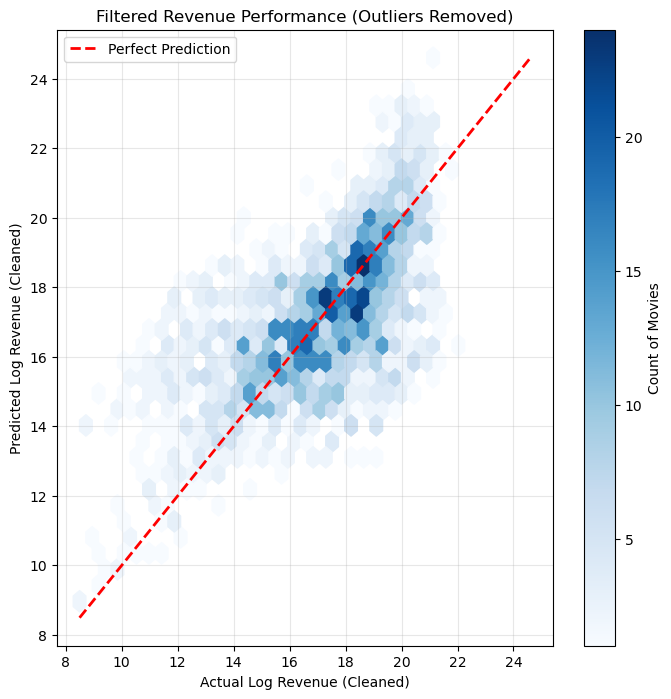

Removed 41 outlier points.


In [26]:
model.eval()
actual_revenues = []
predicted_revenues = []

print("Gathering validation results for scatter plot...")
with torch.no_grad():
    for images, genres, revenues in val_loader:
        images, revenues = images.to(DEVICE), revenues.to(DEVICE)
        _, revenue_pred = model(images)
        
        # Move to CPU and convert to numpy
        actual_revenues.extend(revenues.view(-1).cpu().numpy())
        predicted_revenues.extend(revenue_pred.view(-1).cpu().numpy())

import numpy as np
import matplotlib.pyplot as plt

# 1. Convert to numpy for easy filtering
actuals = np.array(actual_revenues)
preds = np.array(predicted_revenues)

# 2. Calculate Residuals (Errors)
residuals = actuals - preds

# 3. Define Filters
# Filter A: Keep only movies with Actual Log Revenue > 8 (~$3,000)
# Filter B: Remove the top 2% of most extreme errors (statistical outliers)
lower_limit = 8 
residual_threshold = np.percentile(np.abs(residuals), 98)

mask = (actuals > lower_limit) & (np.abs(residuals) < residual_threshold)

filtered_actuals = actuals[mask]
filtered_preds = preds[mask]

# 4. Re-plot the Cleaned Data
plt.figure(figsize=(8, 8))

# Use 'hexbin' or a lower alpha to handle the high density of points
plt.hexbin(filtered_actuals, filtered_preds, gridsize=30, cmap='Blues', mincnt=1)
cb = plt.colorbar(label='Count of Movies')

# Calculate min and max for the diagonal line
min_val = min(filtered_actuals.min(), filtered_preds.min())
max_val = max(filtered_actuals.max(), filtered_preds.max())

# Perfect prediction line
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Log Revenue (Cleaned)')
plt.ylabel('Predicted Log Revenue (Cleaned)')
plt.title('Filtered Revenue Performance (Outliers Removed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Removed {len(actuals) - len(filtered_actuals)} outlier points.")

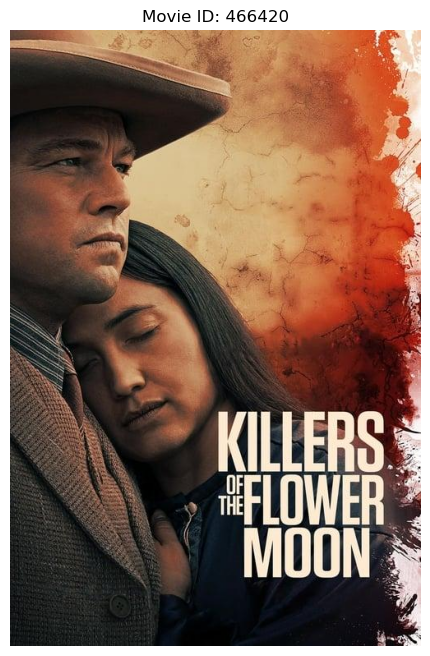

METRIC               | ACTUAL (Truth)            | PREDICTED (Model)        
---------------------------------------------------------------------------
Genres               | Crime, History, Drama     | Action, Drama, Thriller  
Adj. Revenue         | $169,826,828.85           | $609,848.62              

Revenue Error: -99.64%

Top 3 Genre Probabilities:
  Drama: 63.1%
  Action: 40.6%
  Thriller: 38.4%


In [40]:
# Cell 10: Predict vs. Actual Comparison
import matplotlib.pyplot as plt

def compare_prediction(movie_id):
    model.eval()
    image_path = os.path.join(IMAGE_DIR, f"{movie_id}.jpg")
    
    try:
        # 1. Fetch Actual Data from DataFrame
        # We look up the row where 'id' matches our movie_id
        actual_row = df_encoded[df_encoded['id'] == movie_id].iloc[0]
        actual_genres = actual_row['genres']
        actual_rev_adj = actual_row['revenue_adj']
        
        # 2. Prepare Image for Model
        original_img = Image.open(image_path).convert('RGB')
        img_tensor = val_transform(original_img).unsqueeze(0).to(DEVICE)
        
        # 3. Model Inference
        with torch.no_grad():
            genre_logits, revenue_pred = model(img_tensor)
            
        # 4. Process Model Outputs
        probs = torch.sigmoid(genre_logits).cpu().numpy()[0]
        pred_genres = [mlb.classes_[i] for i, p in enumerate(probs) if p > 0.3]
        pred_rev_adj = np.expm1(revenue_pred.item())
        
        # 5. Visualization
        plt.figure(figsize=(6, 8))
        plt.imshow(original_img)
        plt.axis('off')
        plt.title(f"Movie ID: {movie_id}")
        plt.show()
        
        # 6. Comparison Table
        print(f"{'METRIC':<20} | {'ACTUAL (Truth)':<25} | {'PREDICTED (Model)':<25}")
        print("-" * 75)
        
        # Genre Comparison
        actual_genre_str = ", ".join(actual_genres)
        pred_genre_str = ", ".join(pred_genres) if pred_genres else "None (>20%)"
        print(f"{'Genres':<20} | {actual_genre_str:<25} | {pred_genre_str:<25}")
        
        # Revenue Comparison
        actual_rev_str = f"${actual_rev_adj:,.2f}"
        pred_rev_str = f"${pred_rev_adj:,.2f}"
        
        # 2. Now print them with the alignment
        print(f"{'Adj. Revenue':<20} | {actual_rev_str:<25} | {pred_rev_str:<25}")
        
        # Error Calculation
        error_pct = ((pred_rev_adj - actual_rev_adj) / actual_rev_adj) * 100
        print(f"\nRevenue Error: {error_pct:+.2f}%")

        top_indices = probs.argsort()[-3:][::-1]

        print("\nTop 3 Genre Probabilities:")

        for idx in top_indices:

            print(f"  {mlb.classes_[idx]}: {probs[idx]:.1%}")
        
    except IndexError:
        print(f"Error: Movie ID {movie_id} not found in the filtered dataframe.")
    except FileNotFoundError:
        print(f"Error: Image for ID {movie_id} not found at {image_path}")

random_val_movie = val_df.sample(1).iloc[0]
compare_prediction(466420)

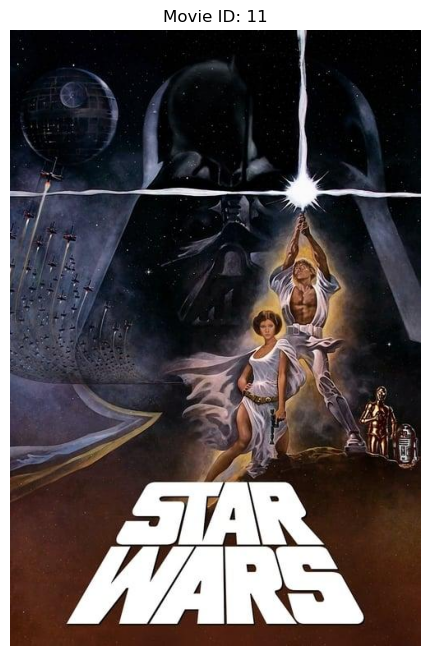

METRIC               | ACTUAL (Truth)            | PREDICTED (Model)        
---------------------------------------------------------------------------
Genres               | Adventure, Action, Science Fiction | Action, Adventure, Science Fiction
Adj. Revenue         | $4,170,946,159.41         | $15,578,330,708.99       

Revenue Error: +273.50%

Top 3 Genre Probabilities:
  Action: 89.2%
  Adventure: 61.8%
  Science Fiction: 61.4%


In [41]:
compare_prediction(11)

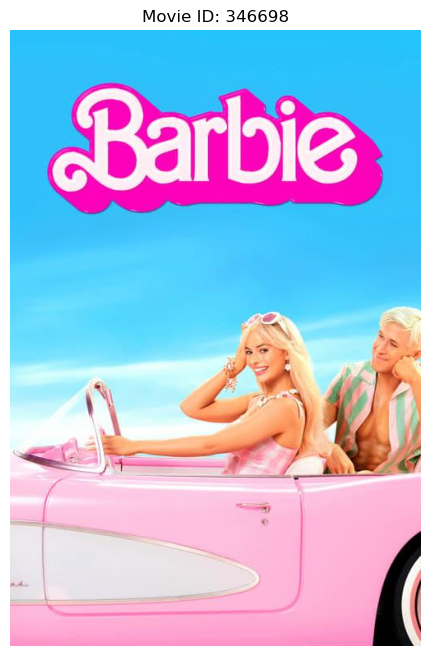

METRIC               | ACTUAL (Truth)            | PREDICTED (Model)        
---------------------------------------------------------------------------
Genres               | Comedy, Adventure         | Adventure, Comedy, Family
Adj. Revenue         | $1,548,380,195.95         | $7,186,025,344.76        

Revenue Error: +364.10%

Top 3 Genre Probabilities:
  Comedy: 95.9%
  Adventure: 39.8%
  Family: 31.8%


In [42]:
compare_prediction(346698)

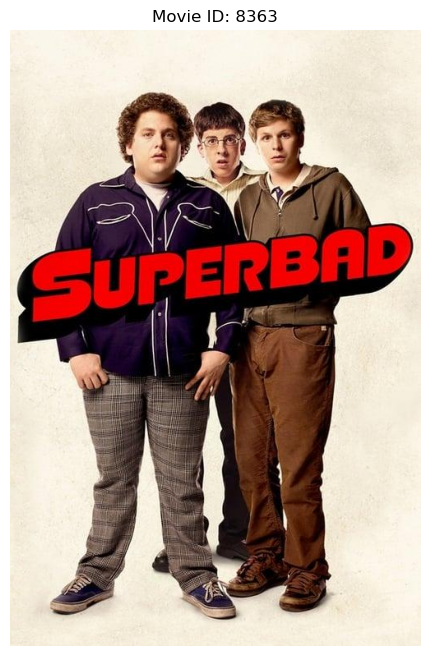

METRIC               | ACTUAL (Truth)            | PREDICTED (Model)        
---------------------------------------------------------------------------
Genres               | Comedy                    | Action, Comedy           
Adj. Revenue         | $268,560,387.67           | $582,314,838.09          

Revenue Error: +116.83%

Top 3 Genre Probabilities:
  Comedy: 81.5%
  Action: 42.4%
  Crime: 19.9%


In [43]:
compare_prediction(8363)

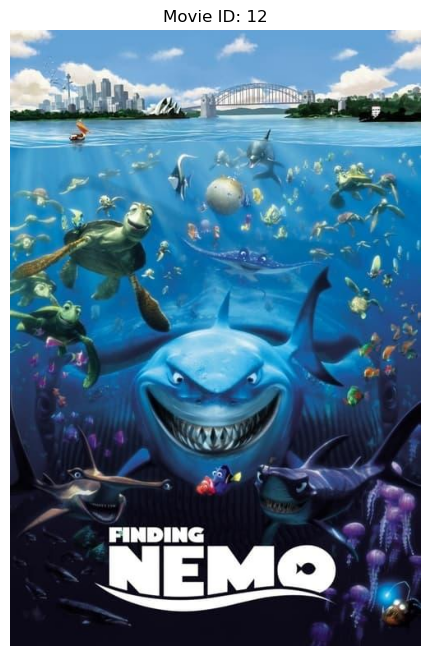

METRIC               | ACTUAL (Truth)            | PREDICTED (Model)        
---------------------------------------------------------------------------
Genres               | Animation, Family, Adventure | Action, Adventure, Animation, Family, Fantasy, Science Fiction
Adj. Revenue         | $1,666,501,187.46         | $16,824,000.88           

Revenue Error: -98.99%

Top 3 Genre Probabilities:
  Animation: 69.6%
  Adventure: 59.5%
  Fantasy: 55.4%


In [47]:
compare_prediction(12)

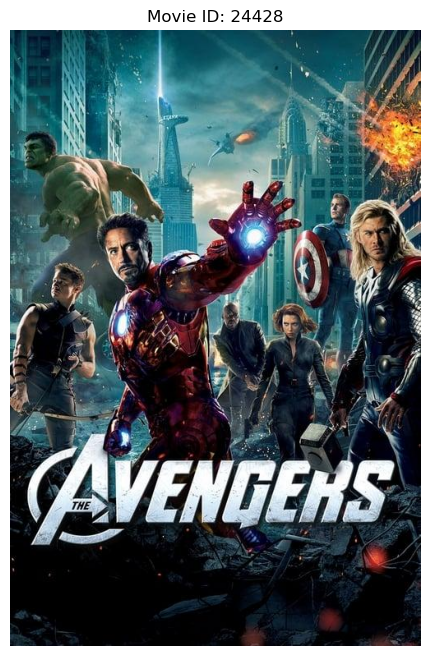

METRIC               | ACTUAL (Truth)            | PREDICTED (Model)        
---------------------------------------------------------------------------
Genres               | Science Fiction, Action, Adventure | Action, Adventure, Science Fiction
Adj. Revenue         | $2,156,685,870.28         | $2,537,965,856.59        

Revenue Error: +17.68%

Top 3 Genre Probabilities:
  Action: 93.6%
  Adventure: 79.9%
  Science Fiction: 67.2%


In [48]:
compare_prediction(24428)

In [15]:
import os

def get_size_format(b, factor=1024, suffix="B"):
    """Scales bytes to its proper format (e.g. 1.20MB)"""
    for unit in ["", "K", "M", "G", "T", "P"]:
        if b < factor:
            return f"{b:.2f}{unit}{suffix}"
        b /= factor

# Paths to your files
model_path = "multitask_resnet_movie_model.pth"
dataset_path = "metadata_final.csv"
posters_dir = "./posters"

print("--- Storage Audit ---")

# 1. Model Weights
if os.path.exists(model_path):
    size = os.path.getsize(model_path)
    print(f"Model File:    {get_size_format(size)}")
else:
    print("Model File:    NOT FOUND")

# 2. Metadata CSV
if os.path.exists(dataset_path):
    size = os.path.getsize(dataset_path)
    print(f"Metadata CSV:  {get_size_format(size)}")
else:
    print("Metadata CSV:  NOT FOUND")

# 3. Posters Folder (Total size of all .jpg files)
if os.path.exists(posters_dir):
    total_size = 0
    img_count = 0
    for f in os.listdir(posters_dir):
        if f.endswith(('.jpg', '.jpeg', '.png')):
            total_size += os.path.getsize(os.path.join(posters_dir, f))
            img_count += 1
    print(f"Posters Dir:   {get_size_format(total_size)} ({img_count} images)")
else:
    print("Posters Dir:   NOT FOUND")

--- Storage Audit ---
Model File:    98.05MB
Metadata CSV:  775.39KB
Posters Dir:   491.01MB (8834 images)
